<a href="https://colab.research.google.com/github/Apoorv070/AI-Agent-Revison-Notebooks/blob/main/5_Final_Langraphs_contd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LangGraph Session 2 — Revision of State, Messages, Tools, and Business Workflows

In the last session, we learned how LangGraph works at a basic level:
- a graph starts from `START` and eventually reaches `END`
- nodes do work
- edges control the flow
- state carries data through the graph
- tools let an LLM access external capabilities
- conditional edges let us route to different paths

Today, we are revising the same ideas, but with more realistic business examples.

The goal of this session is not to learn new complexity.
The goal is to make our understanding cleaner, stronger, and more practical.

By the end of this notebook, you should be able to answer:

1. What exactly is state in LangGraph?
2. How is custom state different from `MessagesState`?
3. What should live in state and what should stay temporary inside a node?
4. What makes a tool well-designed?
5. When should we use rules, when should we use tools, and when should we use an LLM?

In [1]:
!pip install -qU langgraph langchain langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.0/513.0 kB 35.9 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
import os

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

assert os.environ["OPENAI_API_KEY"], "Please add OPENAI_API_KEY in Colab Secrets first."
print("OPENAI_API_KEY loaded successfully.")

OPENAI_API_KEY loaded successfully.


In [3]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI

## 1. What is LangGraph really made of?

A LangGraph workflow is built from three core things:

### State
State is the shared working memory of the graph.
It is the data the graph knows at a given point in time.

### Nodes
Nodes are the places where work happens.
A node reads the current state, does some work, and returns updates.

### Edges
Edges decide where execution goes next.
Some edges are fixed.
Some edges are conditional.

A useful business analogy is this:

- state = the file moving through departments
- nodes = the departments doing work
- edges = the rules that decide which department handles the file next

So when we say a graph is running, what is really happening is:
the state keeps evolving as nodes do work and edges move control forward.

## 2. The most important distinction of today

Students often mix up four different things:

### What should live in state
Anything that must survive across graph steps.

Examples:
- issue type
- urgency
- policy snippet
- tracking status
- final reply
- retry count

### What should be produced temporarily inside a node
Anything that is useful only for a small moment.

Examples:
- prompt strings
- temporary formatting
- intermediate explanation text
- one-time calculations

### What should be passed to a tool
Only the clean minimum input the tool needs.

Examples:
- policy topic
- order id
- customer id

### What should be shown to the LLM
Only the information needed for the current reasoning step.

Very important idea:

Just because the graph knows something does not mean the LLM should always see it.

## 3. State: what it is and what it is not

State is:
- shared runtime context
- evolving information
- the graph's short-term memory for the current run
- the common space through which nodes coordinate

State is not:
- the prompt itself
- every temporary string we ever create
- always the same thing as chat history
- something that must be blindly shown to the LLM

A good state schema is:
- meaningful
- small enough to inspect
- named in business language
- easy to debug

Bad field names:
- x
- data1
- result2
- temp

Good field names:
- issue_type
- urgency
- shipment_status
- refund_eligible
- final_reply

## 4. Example 1 — IT Helpdesk Ticket Assistant

We start with a very simple business workflow.

A user says:

> "My VPN is not connecting and I need access before today's client call."

We want the graph to do four things:
1. read the complaint
2. classify the issue
3. detect urgency
4. draft a reply

This is a very good example of **custom state**.

There is no need for:
- long conversation history
- tools
- an LLM

This shows that LangGraph is not only for fancy chatbots.
It is also useful for structured business workflows.

In [4]:
class HelpdeskState(TypedDict):
    user_message: str
    issue_type: str
    urgency: str
    needs_tool: str
    tool_context: str
    reply_text: str

In [9]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [10]:
from pydantic import BaseModel, Field
class ClassificationOutput(BaseModel):
    issue_type: Literal[
        "VPN / Access Issue",
        "Authentication Issue",
        "Hardware Issue",
        "General IT Issue"
    ]
    urgency: Literal["High", "Normal"]
    needs_tool: Literal["yes", "no"] = Field(
        description="Say yes only if external information is needed before replying"
    )
classifier = llm.with_structured_output(ClassificationOutput)

In [11]:
def classify_ticket(state: HelpdeskState):
    result = classifier.invoke(f"""
You are classifying an IT helpdesk complaint.

Rules:
- VPN / Access Issue -> vpn, access, office systems, remote connectivity
- Authentication Issue -> password, login, sign-in, otp
- Hardware Issue -> laptop, keyboard, screen, charger, battery
- otherwise -> General IT Issue

Urgency:
- High if there is clear time pressure like today, urgent, asap, client call
- otherwise Normal

needs_tool:
- yes if you need external help article, status information, or policy info before replying
- otherwise no

User message:
{state["user_message"]}
""")

    return {
        "issue_type": result.issue_type,
        "urgency": result.urgency,
        "needs_tool": result.needs_tool,
    }

In [12]:
state = HelpdeskState()
state['user_message'] = "I need help with my laptop urgently"
classify_ticket(state)

{'issue_type': 'Hardware Issue', 'urgency': 'High', 'needs_tool': 'no'}

In [13]:
def draft_reply(state: HelpdeskState):
    tool_text = state.get("tool_context", "")

    response = llm.invoke(f"""
You are an IT helpdesk assistant.

Write a short professional reply in 3-4 lines.

User message: {state["user_message"]}
Issue type: {state["issue_type"]}
Urgency: {state["urgency"]}
Extra context: {tool_text}
""")

    return {"reply_text": response.content}


In [16]:
builder = StateGraph(HelpdeskState)
builder.add_node("classify_ticket", classify_ticket)
builder.add_node("draft_reply", draft_reply)
builder.add_edge(START, "classify_ticket")
builder.add_edge("classify_ticket", "draft_reply")
builder.add_edge("draft_reply", END)

graph = builder.compile()

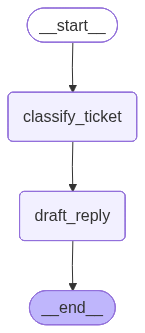

In [17]:
graph

In [18]:
query = input("What's your complaint: ")
result = graph.invoke({"user_message": [HumanMessage(query)]})

# print("FULL FLOW")
# for i, msg in enumerate(result['user_message'], start = 1):
#   print(f"Message{i}: {type(msg).__name__}")
#   print(msg)
#   print()

What's your complaint: i need to fix my mac laptop for software


In [19]:
result

{'user_message': [HumanMessage(content='i need to fix my mac laptop for software', additional_kwargs={}, response_metadata={})],
 'issue_type': 'Hardware Issue',
 'urgency': 'Normal',
 'needs_tool': 'no',
 'reply_text': "Hello, \n\nThank you for reaching out. To assist you with your Mac laptop's software issue, could you please provide more details about the specific problem you're experiencing? This will help us guide you more effectively. \n\nBest regards,  \n[Your Name]  \nIT Helpdesk"}

## 6. Example 2 — Leave Policy Assistant with a Tool

Now let us revise tools.

Scenario:

An employee asks:

> "Can I combine casual leave with the weekend and take 5 days off?"

Here the assistant should not guess the policy.
It should **consult a tool**.

This is the key reason tools exist:
they give the graph access to an external capability or knowledge source.

A tool should have:
- one clear purpose
- narrow inputs
- predictable outputs

Bad tool design:
`handle_everything(query)`

Good tool design:
- `get_leave_policy(policy_topic)`
- `fetch_order_status(order_id)`
- `lookup_customer_profile(customer_id)`

In [20]:
@tool
def get_leave_policy(policy_topic: str) -> str:
    """Fetch a short HR leave-policy snippet for a given topic."""
    policy_db = {
        "casual leave": (
            "Casual leave can be combined with weekends if manager approval is obtained. "
            "The employee must also have sufficient leave balance."
        ),
        "sick leave": (
            "Sick leave is meant for illness-related absence. Medical proof may be required "
            "for longer durations."
        ),
        "earned leave": (
            "Earned leave can be planned in advance and usually needs prior approval from the reporting manager."
        ),
    }

    topic = policy_topic.strip().lower()
    return policy_db.get(
        topic,
        "No exact policy snippet found. Try topics like: casual leave, sick leave, earned leave."
    )

In [21]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

llm = llm.bind_tools([get_leave_policy])
def hr_helpdesk(state:MessagesState):
  prompt = "Imagine you're an HR assistant, answer HR related queries"
  response = llm.invoke(state['messages'])
  return {"messages":[response]}

In [22]:
query = input("Enter the query?: ")
state = MessagesState()
state['messages'] = query
hr_helpdesk(state)

Enter the query?: tell me about leave policy


{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 56, 'total_tokens': 72, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_baaa53d70d', 'id': 'chatcmpl-DVG2aflfcgvsGHaaCYsmm16OGtB9C', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d963e-eceb-7640-bac7-aa41ebfa399e-0', tool_calls=[{'name': 'get_leave_policy', 'args': {'policy_topic': 'general'}, 'id': 'call_CnRHv2aT4tXf810bxx1ifFME', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 56, 'output_tokens': 16, 'total_tokens': 72, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea

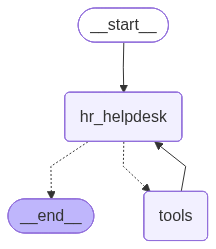

In [23]:
builder = StateGraph(MessagesState)
builder.add_node("hr_helpdesk", hr_helpdesk)
builder.add_edge(START, "hr_helpdesk")
builder.add_node("tools", ToolNode([get_leave_policy]))
builder.add_conditional_edges("hr_helpdesk", tools_condition)
builder.add_edge("hr_helpdesk", END)
builder.add_edge("tools", "hr_helpdesk")
graph = builder.compile()
graph

In [24]:
query = input("Ask me anything: ")
result = graph.invoke({"messages": [HumanMessage(query)]})

print("FULL FLOW")
for i, msg in enumerate(result['messages'], start = 1):
  print(f"Message{i}: {type(msg).__name__}")
  print(msg)
  print()

Ask me anything: tell me about casual elave
FULL FLOW
Message1: HumanMessage
content='tell me about casual elave' additional_kwargs={} response_metadata={} id='b58f1698-c39c-4cfd-926d-98be69f469be'

Message2: AIMessage
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 57, 'total_tokens': 75, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_baaa53d70d', 'id': 'chatcmpl-DVG3Pmet9ZA8ABDO1t1uwX3IWqUCc', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d963f-b483-7f22-8d18-807c68089678-0' tool_calls=[{'name': 'get_leave_policy', 'args': {'policy_topic': 'casual leave'}, 'id': 'call_lxsFvfoviqhaD4nvtaHOEKBC', 'type': 'tool_call'}] 

## 9. Example 3 — Order Support Workflow with Messages + Business Fields

Suppose a customer says:

> "My order has not arrived and the tracking page is not updating."

Now imagine the system needs to keep both:
- chat messages
- business variables like order id, shipment status, refund eligibility

This is very realistic.

If we only keep messages, business fields become buried inside text.
If we only keep business fields, we lose conversational continuity.

So in many real workflows, we combine both.

In [25]:
def fetch_tracking_update(order_id):
    tracking_db = {
        "ORD1001": "Out for delivery",
        "ORD1002": "Delayed in transit",
        "ORD1003": "Delivered",
        "ORD1004": "Lost in transit"
    }

    status = tracking_db.get(order_id, "Tracking not found")

    return {
        "shipment_status": status,
        "messages": [
            AIMessage(
                content=f"Internal update: latest shipment status for order {order_id} is '{status}'."
            )
        ]
    }


def evaluate_refund_eligibility(status):
    status = status.lower()

    if "lost" in status or "delayed" in status:
        refund_eligible = "Yes"
    else:
        refund_eligible = "No"

    return {"refund_eligible": refund_eligible}

In [26]:
# CELL 1 — Imports

from typing import Literal
from typing_extensions import TypedDict, Annotated

from langchain_core.messages import AnyMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [27]:
# CELL 3 — Tools
# Keep them simple. Just return text.

@tool
def fetch_tracking_update(order_id: str) -> str:
    """
    Fetch the latest shipment status for a given order ID.

    Use this when the assistant needs the most recent tracking update
    before replying to the customer.

    Args:
        order_id: The order identifier, such as ORD1002.

    Returns:
        The latest shipment status as plain text.
    """
    tracking_db = {
        "ORD1001": "Out for delivery",
        "ORD1002": "Delayed in transit",
        "ORD1003": "Delivered",
        "ORD1004": "Lost in transit"
    }

    return tracking_db.get(order_id, "Tracking not found")


@tool
def evaluate_refund_eligibility(shipment_status: str) -> str:
    """
    Evaluate whether the customer is eligible for a refund
    based on the shipment status.

    Use this after shipment status is known.

    Args:
        shipment_status: The latest shipment status text.

    Returns:
        'Yes' if refund is eligible, otherwise 'No'.
    """
    status = shipment_status.lower()

    if "lost" in status or "delayed" in status:
        return "Yes"
    return "No"

In [28]:
# CELL 4 — LLM with tools

tools = [fetch_tracking_update, evaluate_refund_eligibility]

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

In [30]:
class OrderState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    order_id: str
    shipment_status: str
    refund_eligible: str

In [32]:
# CELL 5 — Assistant node
# Same node does all reasoning:
# - decides whether to call a tool
# - decides the order of tools
# - replies once enough information is available

def assistant(state: OrderState):
    system_prompt = f"""
You are an order support assistant.

You are working inside a workflow that keeps:
- chat messages
- business fields

Current business fields:
- order_id: {state.get("order_id", "")}
- shipment_status: {state.get("shipment_status", "")}
- refund_eligible: {state.get("refund_eligible", "")}

Rules:
1. If shipment_status is empty, call fetch_tracking_update.
2. If shipment_status is available but refund_eligible is empty, call evaluate_refund_eligibility.
3. Once you have enough information, write a short professional reply to the customer.
4. Do not invent shipment status or refund eligibility.
5. Keep the final response short and support-like.
"""

    response = llm_with_tools.invoke(
        [SystemMessage(content=system_prompt)] + state["messages"]
    )

    return {"messages": [response]}

In [33]:
state = OrderState()
state["messages"] = ["I need my refund for my order"]
assistant(state)

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 291, 'total_tokens': 307, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0464f29e8b', 'id': 'chatcmpl-DVGBdR7aVs7RY3NiuHhMqtnEu5UT1', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9647-7cad-7450-a878-cee52d4c2e4f-0', tool_calls=[{'name': 'fetch_tracking_update', 'args': {'order_id': ''}, 'id': 'call_N9UJ2Mpzz71BeEwEU1Iv4pry', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 291, 'output_tokens': 16, 'total_tokens': 307, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reaso

In [34]:
state = OrderState()
state["messages"] = ["I need my refund for my order", AIMessage("May I have your order id"), "Yes it is ORD1001"]
assistant(state)

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 311, 'total_tokens': 329, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a64aa7d0ff', 'id': 'chatcmpl-DVGBjn6SRYxHgySJCgaVpK5GCDoXk', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d9647-954a-7ae1-a048-8980eed20eb9-0', tool_calls=[{'name': 'fetch_tracking_update', 'args': {'order_id': 'ORD1001'}, 'id': 'call_OcPxKFxrtAQXj3azMvQgb1ix', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 311, 'output_tokens': 18, 'total_tokens': 329, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,

In [35]:
state

{'messages': ['I need my refund for my order',
  AIMessage(content='May I have your order id', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  'Yes it is ORD1001']}

In [36]:
def router(state: OrderState) -> Literal["tools", END]:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [37]:
builder = StateGraph(OrderState)
builder.add_node("assistant", assistant)
tool_node = ToolNode([evaluate_refund_eligibility, fetch_tracking_update])
builder.add_node("tools", tool_node)
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")
graph = builder.compile()

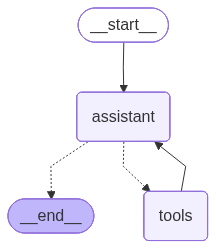

In [38]:
graph

In [39]:
query = input("Query about your order: ")
result = graph.invoke({"messages": [HumanMessage(query)]})

print("FULL FLOW")
for i, msg in enumerate(result['messages'], start = 1):
  print(f"Message{i}: {type(msg).__name__}")
  print(msg)
  print()

Query about your order: what is status of ORD1002
FULL FLOW
Message1: HumanMessage
content='what is status of ORD1002' additional_kwargs={} response_metadata={} id='f14a6798-d9ac-4d14-9ddb-5a8180216aaa'

Message2: AIMessage
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 291, 'total_tokens': 309, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a64aa7d0ff', 'id': 'chatcmpl-DVGCQu2t5LEdzk7Ml0bIs8fB3T9pw', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d9648-3fc8-7d02-93be-db62d5096694-0' tool_calls=[{'name': 'fetch_tracking_update', 'args': {'order_id': 'ORD1002'}, 'id': 'call_c5UT9EOnFUhr4RsG9lOgLRQz', 'type': 'tool_call'

- 1. Create your tools with docstring
- 2. Bind your llm with tools
- 3. Define your state
- 4. Make your llm node and test it. (You may need to bind llm with pydantic)
- 5. Make your router
- 6. Build your langraph